# 01 — Calculus, automatic differentiation, and neural fields

**Level:** introductory  
**Question:** *How can a neural network behave like a differentiable physical field?*

You will derive derivatives of a tiny network, distinguish automatic differentiation
from finite differences, construct a residual for an ODE, and train your first PINN.

In [4]:
from pathlib import Path
import sys

import autograd.numpy as anp
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import numpy as np

# Find the shared teaching utilities even if Jupyter was launched one directory above.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "pinnlab.py").exists():
        COURSE_ROOT = candidate
        break
else:
    raise FileNotFoundError("Run this notebook from the course directory containing pinnlab.py")

sys.path.insert(0, str(COURSE_ROOT))
from pinnlab import adam, gradient_cosine, init_mlp, mlp, relative_l2, set_plot_style

set_plot_style()
np.set_printoptions(precision=4, suppress=True)

from autograd import elementwise_grad

## 1. A derivative is the local statement of physics

Consider exponential relaxation

$
\frac{du}{dx}+u=0,\qquad u(0)=1.
$

Separation of variables gives

$
\frac{du}{u}=-dx
\quad\Rightarrow\quad
\log u=-x+C
\quad\Rightarrow\quad
u(x)=e^{-x}.
$

A candidate $\tilde u$ is a solution only if both its value at the anchor and its
local slope-value relation are correct. This already contains the PINN idea.

## 2. Hand differentiation of one neuron

For

$
N(x)=a\tanh(wx+b)+c,
$

the chain rule gives

$
N'(x)=aw\left[1-\tanh^2(wx+b)\right],
$

$
N''(x)=-2aw^2\tanh(wx+b)\left[1-\tanh^2(wx+b)\right].
$

A multilayer network is just a much larger composition. Automatic differentiation
(AD) applies the chain rule to the computation graph with machine precision. It is
neither symbolic algebra nor a finite-difference approximation.

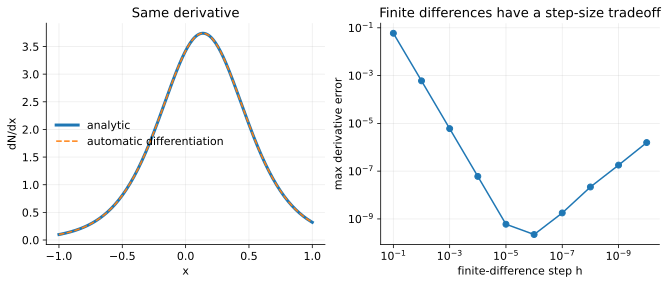

In [6]:
# Compare analytic, automatic, and centered finite-difference derivatives.
a, w, b, c = 1.7, 2.2, -0.3, 0.1

def one_neuron(x):
    return a * anp.tanh(w*x + b) + c

d_one = elementwise_grad(one_neuron)
x = np.linspace(-1, 1, 200)
analytic = a*w*(1 - np.tanh(w*x + b)**2)
automatic = np.asarray(d_one(anp.asarray(x)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, analytic, label="analytic", lw=3)
axes[0].plot(x, automatic, "--", label="automatic differentiation")
axes[0].set(title="Same derivative", xlabel="x", ylabel="dN/dx")
axes[0].legend()

hs = np.logspace(-1, -10, 10)
fd_errors = []
for h in hs:
    fd = (np.asarray(one_neuron(x+h)) - np.asarray(one_neuron(x-h))) / (2*h)
    fd_errors.append(np.max(np.abs(fd - analytic)))
axes[1].loglog(hs, fd_errors, "o-")
axes[1].invert_xaxis()
axes[1].set(title="Finite differences have a step-size tradeoff",
            xlabel="finite-difference step h", ylabel="max derivative error");

For large $h$, truncation error dominates; for tiny $h$, floating-point
cancellation dominates. AD has no differencing step, although it still inherits
floating-point and conditioning issues.

**Activation regularity matters.** A strong-form PDE containing $u_{xx}$ asks
the trial field for second derivatives. ReLU networks are piecewise linear, so
their classical second derivative is zero almost everywhere and undefined at
kinks. Smooth activations such as `tanh`, sine, or softplus are safer defaults.
Weak forms can lower the derivative requirement.

## 3. Turn the ODE into a residual

Choose a network $N_\theta(x)$ and enforce the initial value exactly with

$
u_\theta(x)=1+xN_\theta(x).
$

Because \(u_\theta(0)=1\) for every \(\theta\), optimization only needs to reduce

$
r_\theta(x)=\frac{du_\theta}{dx}+u_\theta,
\qquad
\widehat{\mathcal L}(\theta)=\frac1{N_r}\sum_i r_\theta(x_i)^2.
$

This is an **exact constraint map**: parameter space has been mapped directly into
the set of admissible fields.

In [7]:
layers = [1, 16, 16, 1]
theta0 = init_mlp(layers, seed=1)
x_r = anp.linspace(0.0, 2.0, 48)

def raw_network(theta, x):
    return mlp(theta, x[:, None], layers)[:, 0]

def u(theta, x):
    return 1.0 + x * raw_network(theta, x)

def u_x(theta, x):
    return elementwise_grad(u, 1)(theta, x)

def residual(theta, x):
    return u_x(theta, x) + u(theta, x)

def loss(theta):
    return anp.mean(residual(theta, x_r)**2)

result = adam(loss, theta0, steps=900, learning_rate=3e-3, log_every=50)
print(f"training seconds: {result.elapsed_seconds:.2f}")
print(f"final residual MSE: {result.history['loss'][-1]:.3e}")

training seconds: 1.23
final residual MSE: 4.108e-04


relative L2 field error: 7.612e-03
exact anchor u(0): 1.000000000000


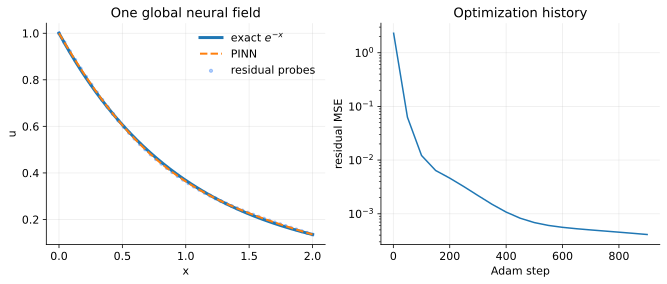

In [8]:
x_test = np.linspace(0, 2, 300)
u_pred = np.asarray(u(result.theta, anp.asarray(x_test)))
u_exact = np.exp(-x_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_test, u_exact, lw=3, label="exact $e^{-x}$")
axes[0].plot(x_test, u_pred, "--", lw=2, label="PINN")
axes[0].scatter(np.asarray(x_r), np.asarray(u(result.theta, x_r)), s=10,
                color="#3b82f6", alpha=.4, label="residual probes")
axes[0].set(xlabel="x", ylabel="u", title="One global neural field")
axes[0].legend()

axes[1].semilogy(result.history["step"], result.history["loss"])
axes[1].set(xlabel="Adam step", ylabel="residual MSE", title="Optimization history")

print(f"relative L2 field error: {relative_l2(u_pred, u_exact):.3e}")
print(f"exact anchor u(0): {float(u(result.theta, anp.array([0.0]))[0]):.12f}")

## 4. Read the code as mathematics

- `raw_network` defines the trial family.
- `u = 1 + x*N` defines the admissible set.
- `elementwise_grad` constructs jet coordinates.
- `residual` evaluates distance from the physics manifold.
- `x_r` and the mean define an empirical measure.
- Adam searches parameter space; it does not know any physics itself.

### Exercises

1. Replace the ODE by $u_x+2u=0$. Predict the solution before running.
2. Replace `tanh` in `pinnlab.py` by a nonsmooth activation and inspect the
   second derivative of the network.
3. Train on $x\in[0,1]$, then evaluate on $[1,2]$. Is physics-informed
   extrapolation guaranteed outside the collocation domain?
4. Derive an exact map for two anchors $u(0)=a$, $u(1)=b$.

**Checkpoint:** AD makes residual evaluation exact *for the represented neural
function*; it does not make the neural function an exact solution.